In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/OS_Training_Ready_Blind.csv.gz'
df_os = pd.read_csv(file_path, compression='gzip', low_memory=False)

print(f"Dataset Loaded: {df_os.shape[0]} rows")
print(f"Target Label present: {'True_Label' in df_os.columns}")
all_cols = sorted(df_os.columns.tolist())

print(f"Total Columns: {len(all_cols)}")
print("-" * 30)
for col in all_cols:
    print(col)
df_os.head()
df_os.shape

Dataset Loaded: 122563 rows
Target Label present: False
Total Columns: 160
------------------------------
Malicious_Label
_id
_index
_source.agent.id
_source.agent.ip
_source.agent.name
_source.data.arch
_source.data.audit.arch
_source.data.audit.cwd
_source.data.audit.egid
_source.data.audit.euid
_source.data.audit.exe
_source.data.audit.execve.a0
_source.data.audit.execve.a1
_source.data.audit.execve.a2
_source.data.audit.execve.a3
_source.data.audit.execve.a4
_source.data.audit.execve.a5
_source.data.audit.execve.a6
_source.data.audit.execve.a7
_source.data.audit.exit
_source.data.audit.file.inode
_source.data.audit.file.mode
_source.data.audit.file.name
_source.data.audit.fsgid
_source.data.audit.fsuid
_source.data.audit.gid
_source.data.audit.id
_source.data.audit.key
_source.data.audit.list
_source.data.audit.pid
_source.data.audit.ppid
_source.data.audit.res
_source.data.audit.session
_source.data.audit.sgid
_source.data.audit.success
_source.data.audit.suid
_source.data.audit.s

(122563, 160)

In [ ]:
irrelevant_cols = ['_id', '_index', 'event_time', 'source_filename', 'mitre_tactic_combined']
df_refined = df_os.drop(columns=[col for col in irrelevant_cols if col in df_os.columns])

text_features = df_refined.select_dtypes(include=['object']).columns
df_refined[text_features] = df_refined[text_features].fillna('none').astype(str)

numeric_features = df_refined.select_dtypes(include=[np.number]).columns
df_refined[numeric_features] = df_refined[numeric_features].fillna(0)
le = LabelEncoder()
for col in text_features:
    df_refined[col] = le.fit_transform(df_refined[col])

print(f"Preprocessing Complete. Features refined: {df_refined.shape[1]}")

Preprocessing Complete. Features refined: 155


Model and feature columns saved successfully


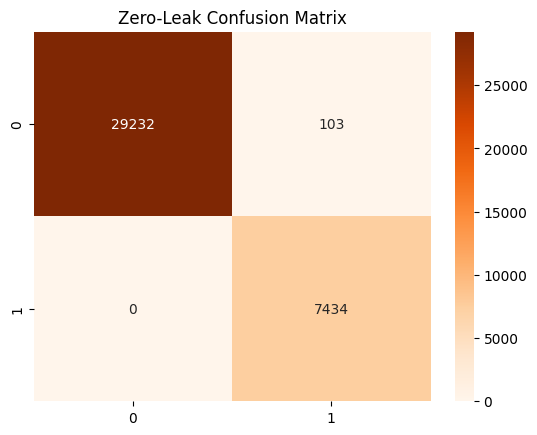

Total Malicious Logs in Test Set: 7434
Malicious Logs Protected: 7434
SUCCESS: ZERO attacks dropped.

Benign logs successfully DROPPED: 29232
Storage Savings: 99.65%


In [ ]:
#GATE KEEPER MODEL TRAINING
X = df_refined.drop(columns=['Malicious_Label'])
y = df_refined['Malicious_Label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

import joblib
print("Model and feature columns saved successfully")
y_probs = rf_model.predict_proba(X_test)[:, 1]
y_pred_ultra_safe = (y_probs > 0.01).astype(int)

cm = confusion_matrix(y_test, y_pred_ultra_safe)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Zero-Leak Confusion Matrix")
plt.show()

total_attacks = (y_test == 1).sum()
protected_attacks = ((y_test == 1) & (y_pred_ultra_safe == 1)).sum()
leaked_attacks = total_attacks - protected_attacks

print(f"Total Malicious Logs in Test Set: {total_attacks}")
print(f"Malicious Logs Protected: {protected_attacks}")

if leaked_attacks == 0:
    print(f"SUCCESS: ZERO attacks dropped.")
else:
    print(f"FAILURE: {leaked_attacks} attacks still leaked. ")
total_benign = (y_test == 0).sum()
dropped_benign = ((y_test == 0) & (y_pred_ultra_safe == 0)).sum()
reduction_rate = (dropped_benign / total_benign) * 100

print(f"\nBenign logs successfully DROPPED: {dropped_benign}")
print(f"Storage Savings: {reduction_rate:.2f}%")

In [ ]:
X_blind = df_refined.drop(columns=['Malicious_Label'], errors='ignore')
print("Gatekeeper is analyzing the logs... ")
y_probs_blind = rf_model.predict_proba(X_blind)[:, 1]

df_os['Gatekeeper_Decision'] = np.where(y_probs_blind > 0.01, 'KEEP', 'DROP')

df_forensic_gold = df_os[df_os['Gatekeeper_Decision'] == 'KEEP'].copy()

print("\n--- FINAL GATEKEEPER EXECUTION REPORT ---")
print(f"Original Logs: {len(df_os)}")
print(f"Boring Logs Dropped: {len(df_os) - len(df_forensic_gold)}")
print(f"Forensic 'Gold' Logs Kept: {len(df_forensic_gold)}")
print(f"Dataset Size Reduction: {((len(df_os) - len(df_forensic_gold)) / len(df_os)) * 100:.2f}%")

lost_attacks = df_forensic_gold[df_forensic_gold['Malicious_Label'] == 1].shape[0]
total_attacks = df_os[df_os['Malicious_Label'] == 1].shape[0]

if lost_attacks == total_attacks:
    print(f"INTEGRITY CONFIRMED: All {total_attacks} APT attacks are present in the Gold dataset.")

Gatekeeper is analyzing the logs... 

--- FINAL GATEKEEPER EXECUTION REPORT ---
Original Logs: 122563
Boring Logs Dropped: 97551
Forensic 'Gold' Logs Kept: 25012
Dataset Size Reduction: 79.59%
INTEGRITY CONFIRMED: All 24779 APT attacks are present in the Gold dataset.


In [ ]:
joblib.dump(rf_model, "/content/drive/MyDrive/Colab Notebooks/os_log_model.pkl")
joblib.dump(X.columns.tolist(), "/content/drive/MyDrive/Colab Notebooks/feature_columns.pkl")

['/content/drive/MyDrive/Colab Notebooks/feature_columns.pkl']